# 룰베이스 트랙 — 실사진 검증

`src/rule_based/`의 `get_mask()`(Otsu + GrabCut) + `classify_shape()`를 `data/`에 있는 실제 텀블러 사진에 돌려서, 세그멘테이션 마스크와 분류 결과를 함께 확인한다.

파일명이 곧 기대 라벨이다 (예: `머그형.jpg` → mug). 자세한 실험 기록은 `docs/experiment-log.md`, 문제 해결 과정은 `docs/troubleshooting.md` 참고.

In [9]:
import sys, os, glob

sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 라벨이 깨지지 않도록 (Windows 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

from rule_based.shape_classifier import get_mask, classify_shape, describe_result_ko, SHAPE_LABELS_KO


def imread_unicode(path):
    """cv2.imread는 Windows 한글 경로에서 조용히 실패하므로 우회한다 (docs/troubleshooting.md 참고)."""
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

In [10]:
DATA_DIR = os.path.join("..", "data")

image_paths = sorted(
    p for p in glob.glob(os.path.join(DATA_DIR, "*.*"))
    if not p.endswith("_mask.png") and os.path.splitext(p)[1].lower() in (".jpg", ".jpeg", ".png")
)
print(f"테스트 이미지 {len(image_paths)}장 발견")
image_paths

테스트 이미지 4장 발견


['..\\data\\단차테이퍼형.jpg',
 '..\\data\\머그형.jpg',
 '..\\data\\연속테이퍼형.jpg',
 '..\\data\\직선원통형.png']

## 사진별 원본 / 마스크 / 분류 결과

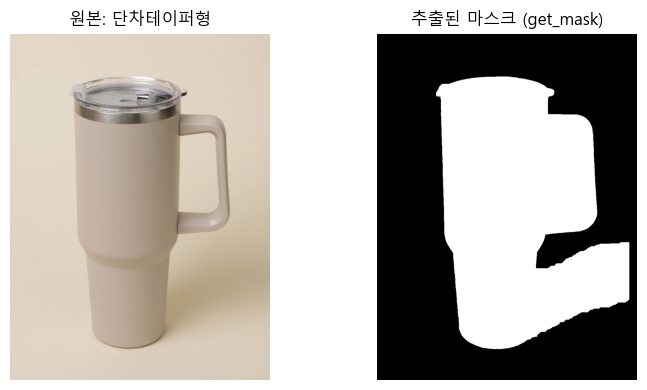

[단차테이퍼형] (기대 라벨: 파일명 기준)
형태            : 단차 테이퍼형 (taper_step)
높이/지름 비율   : 1.58
아래폭/위폭 비율 : 0.89
손잡이 감지      : 예
폭 프로파일(위→아래) : [387.0, 496.0, 499.0, 500.0, 504.0, 501.0, 600.0, 573.0, 565.0, 345.0]
------------------------------------------------------------


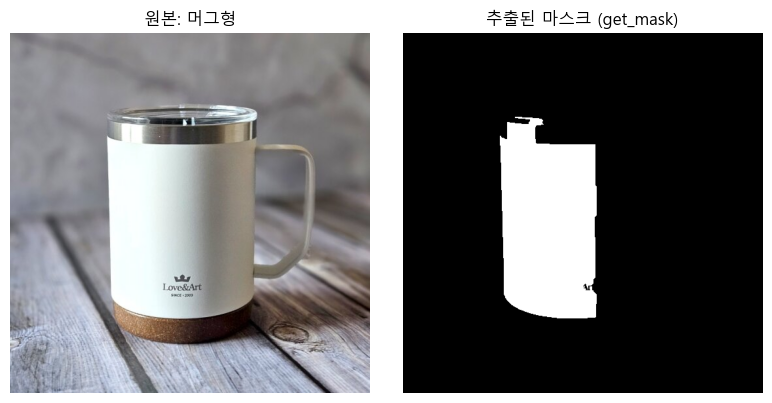

[머그형] (기대 라벨: 파일명 기준)
형태            : 직선 원통형 (straight)
높이/지름 비율   : 2.12
아래폭/위폭 비율 : 2.06
손잡이 감지      : 예
폭 프로파일(위→아래) : [67.0, 146.0, 145.0, 146.0, 145.0, 142.0, 141.0, 140.0, 142.0, 138.0]
------------------------------------------------------------


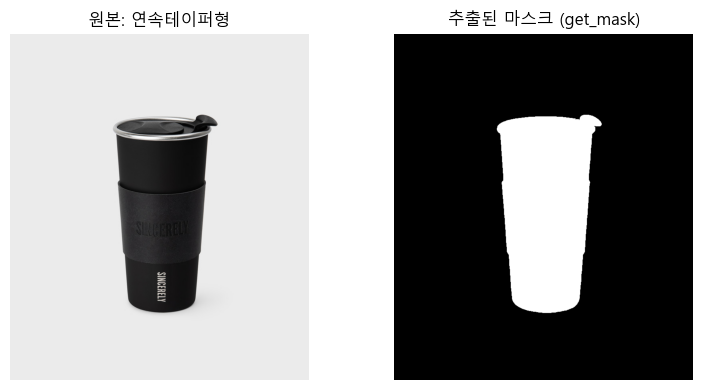

[연속테이퍼형] (기대 라벨: 파일명 기준)
형태            : 연속 테이퍼형 (taper_smooth)
높이/지름 비율   : 1.89
아래폭/위폭 비율 : 0.65
손잡이 감지      : 아니오
폭 프로파일(위→아래) : [263.0, 230.0, 223.0, 222.0, 217.0, 210.0, 201.0, 190.0, 180.0, 172.0]
------------------------------------------------------------


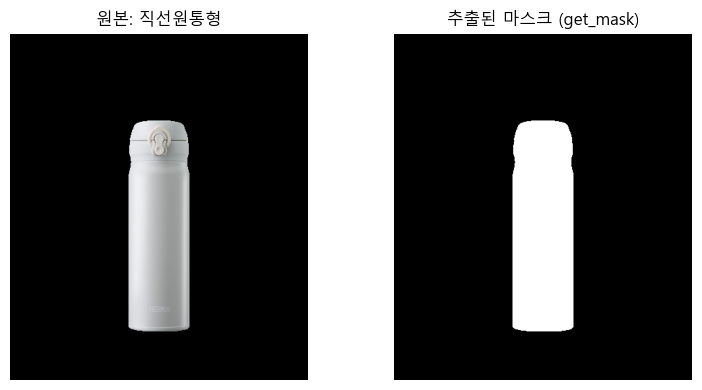

[직선원통형] (기대 라벨: 파일명 기준)
형태            : 직선 원통형 (straight)
높이/지름 비율   : 3.45
아래폭/위폭 비율 : 1.05
손잡이 감지      : 아니오
폭 프로파일(위→아래) : [84.0, 86.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0]
------------------------------------------------------------


In [11]:
results = []

for path in image_paths:
    name = os.path.splitext(os.path.basename(path))[0]
    image = imread_unicode(path)
    mask = get_mask(image)
    result = classify_shape(mask)
    results.append((name, result))

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"원본: {name}")
    axes[0].axis("off")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("추출된 마스크 (get_mask)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"[{name}] (기대 라벨: 파일명 기준)")
    print(describe_result_ko(result))
    print("-" * 60)

## 요약

In [14]:
header = f"{'파일명(실제)':16s} \t{'룰 베이스 예측':22s} \t{'h/d':>6s} \t{'b/t':>6s} \t{'손잡이감지':>8s}"
print(header)
print("-" * 90)
for name, result in results:
    shape_ko = SHAPE_LABELS_KO.get(result["shape"], result["shape"])
    label = f"{shape_ko}({result['shape']})"
    handle = "예" if result["handle_detected"] else "아니오"
    print(f"{name:16s} \t{label:22s} \t{result['height_diameter_ratio']:6.2f} \t{result['bottom_top_ratio']:6.2f} \t{handle:>8s}")

파일명(실제)          	룰 베이스 예측               	   h/d 	   b/t 	   손잡이감지
------------------------------------------------------------------------------------------
단차테이퍼형           	단차 테이퍼형(taper_step)    	  1.58 	  0.89 	       예
머그형              	직선 원통형(straight)       	  2.12 	  2.06 	       예
연속테이퍼형           	연속 테이퍼형(taper_smooth)  	  1.89 	  0.65 	     아니오
직선원통형            	직선 원통형(straight)       	  3.45 	  1.05 	     아니오


**현재 알려진 한계** (2026-09-14 기준, `docs/troubleshooting.md`에 상세 기록):
- 배경 대비가 뚜렷하고 그림자가 적은 사진(연속테이퍼형, 직선원통형)은 마스크가 깨끗하고 분류도 정확함.
- 물체-배경 색이 비슷하거나(머그형: 코르크 받침 vs 나무 바닥) 그림자가 물체에 융착된 사진(단차테이퍼형)은 GrabCut을 적용해도 마스크가 불완전함 — 알고리즘보다 촬영 조건(배경 대비, 조명) 문제에 가까움.